# Project 01: Stock Screener — Exploratory Data Analysis (EDA)

This notebook serves as the foundational Exploratory Data Analysis (EDA) prior to the development of a rule-based quantitative stock screener. 

The primary objective is to evaluate the statistical properties, historical distributions, and correlation regimes of the target asset universe (AAPL, MSFT, SPY) using daily return data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import yfinance as yf
import plotly.express as px

In [2]:
# 1. Re-hydration: Extraction and Normalization (Week 2 logic)
tickers = ["AAPL", "MSFT", "SPY"]
start_date = "2023-01-01"
end_date = "2025-01-01"

market_data_wide = yf.download(tickers, start_date, end_date, auto_adjust=True, progress=False, multi_level_index=True)
market_data = market_data_wide.stack().reset_index()
market_data.columns = market_data.columns.str.lower()
market_data.columns.name = None
market_data = market_data[["date", "ticker", "open", "high", "low", "close", "volume"]]

# 2. Generation of Analytical Base Table in-memory
query = """
WITH previous_prices AS (
    SELECT 
        date, ticker, open, high, low, close, volume,
        LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS previous_close
    FROM market_data
)
SELECT 
    date, ticker, open, high, low, close, volume,
    (close / previous_close) - 1 AS daily_return
FROM previous_prices
ORDER BY ticker, date;
"""

daily_returns = duckdb.sql(query).df()

# 3. Validation
assert daily_returns.shape[1] == 8, "Expected 8 columns in the Analytical Base Table."
assert daily_returns['daily_return'].isna().sum() == 3, "Expected exactly 3 NaNs for daily_return at t_0."
assert daily_returns.duplicated(subset=['date', 'ticker']).sum() == 0, "Duplicate composite primary keys found."

daily_returns.head()

,date,ticker,open,high,low,close,volume,daily_return
0,2023-01-03,AAPL,127.995375,128.604497,121.992521,122.876740,112117500,NaN
1,2023-01-04,AAPL,124.664816,126.403781,122.886559,124.144112,89113600,0.010314
2,2023-01-05,AAPL,124.900605,125.529381,122.572171,122.827606,80962700,-0.010605
3,2023-01-06,AAPL,123.800245,128.005180,122.699883,127.346931,87754700,0.036794
4,2023-01-09,AAPL,128.182056,131.070502,127.612225,127.867661,70790800,0.004089


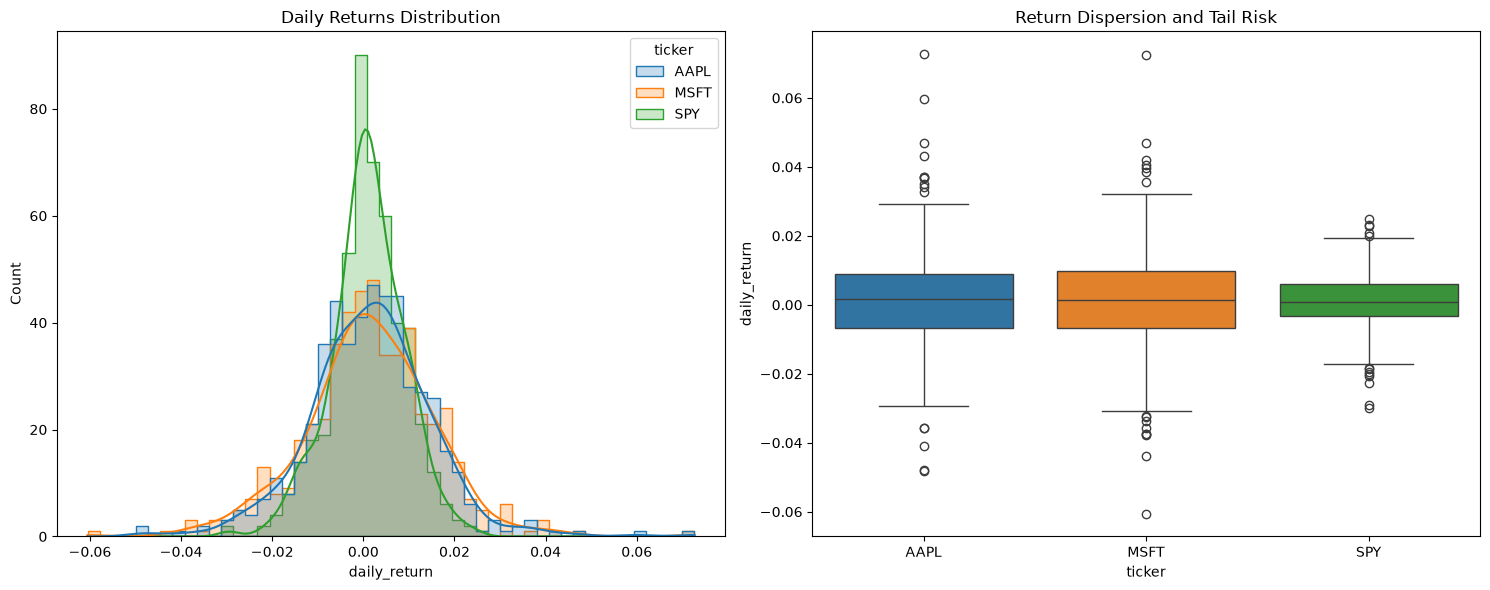

In [3]:
# Dataset Preparation for visualization

# Removing null values
daily_returns_clean = daily_returns.dropna(subset=["daily_return"])

assert daily_returns_clean['daily_return'].isna().sum() == 0, "Expected exactly 0 NaNs for daily_return at t_0."

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

axes[0].set_title("Daily Returns Distribution")
axes[1].set_title("Return Dispersion and Tail Risk")

sns.histplot(data=daily_returns_clean, x="daily_return", hue="ticker", element= "step", kde = True, bins = 50, ax = axes[0])
sns.boxplot(data=daily_returns_clean, x="ticker", y="daily_return", hue="ticker", ax = axes[1])

plt.tight_layout()
plt.show()

### Visual Distribution Analysis
*   **Idiosyncratic Risk vs. Diversification:** The single-stock assets (AAPL, MSFT) exhibit wider distributions and heavier tails (multiple visible outliers) compared to the SPY ETF. 
*   **Market Regime:** The SPY benchmark shows a much tighter Interquartile Range (IQR) and a higher peak (leptokurtic visual profile), effectively demonstrating how cross-sectional diversification mitigates extreme daily volatility.

In [4]:
# Compute Statistical Moments

moments_df = daily_returns_clean.groupby("ticker")["daily_return"].agg([
    "count", "mean", "std", "skew", "kurt", "min", "max"]
)

# Rename columns for clarity (optional but recommended for a clean portfolio)
moments_df.columns = ['Count', 'Mean', 'Volatility', 'Skewness', 'Excess_Kurtosis', 'Min', 'Max']

# Structural Validation
assert moments_df.shape == (3, 7), f"Expected shape (3, 7), got {moments_df.shape}"
assert moments_df.index.nunique() == 3, "Expected exactly 3 unique tickers in the index."
assert moments_df.isna().sum().sum() == 0, "Unexpected NaNs in the statistical moments calculation." 

display(moments_df)

,Count,Mean,Volatility,Skewness,Excess_Kurtosis,Min,Max
ticker,,,,,,,
AAPL,501,0.001498,0.013452,0.262441,2.828012,-0.048167,0.072649
MSFT,501,0.001263,0.014286,-0.017628,1.968729,-0.060528,0.072435
SPY,501,0.000949,0.008075,-0.261002,0.735205,-0.029803,0.024866


### Normal Distribution Analysis
* **Skewness:** The single-stock asset AAPL presents a positive skewness. This is structurally possible during tech-driven rallies where upside gaps push the skewness into positive territory. SPY, conversely, maintains the classic macroeconomic equity profile: negative skewness.
* **Kurtosis:** All three assets exhibit an Excess Kurtosis > 0 (leptokurtic profile). Specifically, the SPY benchmark has the lowest value, aligning with the visual evidence from the previous histogram and boxplot, indicating it most closely approximates a Gaussian distribution. The single-stock assets present significantly higher kurtosis, confirming the presence of 'fat tails' and elevated outlier risk.

In [5]:
# New column creation
daily_returns["rolling_vol_30d_ann"] = daily_returns.groupby("ticker")["daily_return"].transform(lambda x : x.rolling(window=30).std() * np.sqrt(252))

# Column creation check
assert 'rolling_vol_30d_ann' in daily_returns.columns, "Column was not created."

# Cold Start Validation
# 30 NaNs per ticker (29 from rolling + 1 from t_0) = 90 total NaNs
expected_nans = 30 * daily_returns['ticker'].nunique()
actual_nans = daily_returns['rolling_vol_30d_ann'].isna().sum()
assert actual_nans == expected_nans, f"Expected {expected_nans} NaNs, got {actual_nans}"

# Display the first valid rows for AAPL to visually check the calculation
display(daily_returns[daily_returns['ticker'] == 'AAPL'].iloc[28:33])

,date,ticker,open,high,low,close,volume,daily_return,rolling_vol_30d_ann
28,2023-02-13,AAPL,148.529324,151.786241,148.499806,151.382828,62199000,0.018807,NaN
29,2023-02-14,AAPL,149.680558,151.304107,148.440769,150.743240,61707600,-0.004225,NaN
30,2023-02-15,AAPL,150.654695,153.006368,150.428388,152.839096,65573800,0.013903,0.232277
31,2023-02-16,AAPL,151.048297,153.823083,150.890874,151.245102,68167900,-0.010429,0.237734
32,2023-02-17,AAPL,149.906924,150.546495,148.430978,150.103714,59144100,-0.007547,0.235957


In [6]:
fig = px.line(
    daily_returns, # Use of original DataFrame which contains NaN values of the rolling
    x="date", 
    y="rolling_vol_30d_ann", 
    color="ticker", 
    title="Dynamic Risk: 30-Day Rolling Annualized Volatility"
)

# Improving Axes Readability
fig.update_layout(
    yaxis_title="Annualized Volatility",
    xaxis_title="Date",
    hovermode="x unified"
)

fig.show()

### Dynamic Risk & Regime Analysis
The interactive chart illustrates the dynamic 30-day rolling annualized volatility, adding a temporal dimension to the prior static risk assessment. 
* **Diversification Benefit:** Consistent with modern portfolio theory, the heavily diversified SPY benchmark structurally maintains a lower volatility regime compared to the idiosyncratic risk profiles of single-stock tech assets (AAPL, MSFT).
* **Systemic Shocks vs. Idiosyncratic Risk:** The timeline highlights severe systemic volatility spikes—most notably the March 2023 US regional banking liquidity crisis and the August 2024 global VIX shock—causing synchronized cross-asset risk expansion. Conversely, local peaks in individual stocks indicate idiosyncratic events (e.g., earnings reports or product launches).

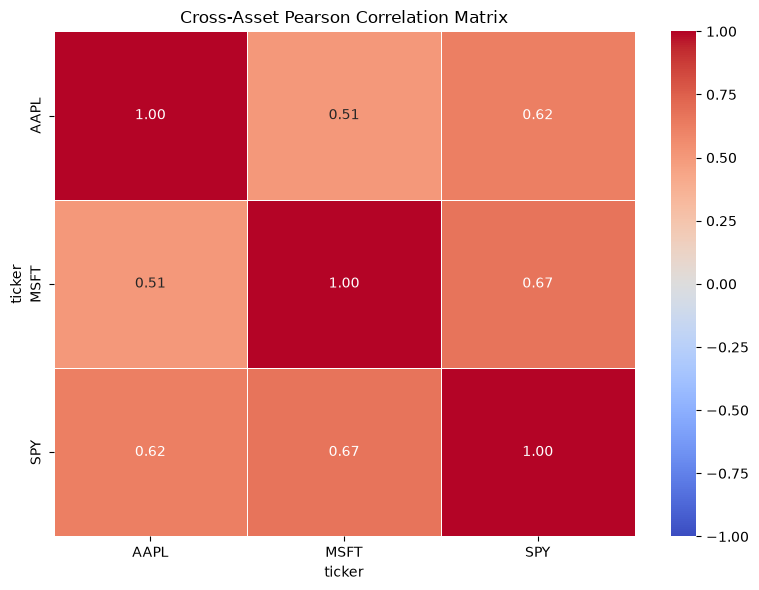

In [18]:
# Dataset from long format to wide format
returns_wide = daily_returns_clean.pivot(index="date", columns="ticker", values="daily_return")

# Computation of Pearson Correlation Matrix
corr_matrix = returns_wide.corr()

# Structural controls
assert corr_matrix.shape == (3,3), "Expected squared matrix of dimensions 3x3"
assert np.isclose(np.trace(corr_matrix), 3.0), "Trace of correlation matrix must equal the number of assets."

# Visualization: Financial Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Cross-Asset Pearson Correlation Matrix")
plt.tight_layout()
plt.show()


### Cross-Asset Correlation & Diversification Analysis
The Pearson correlation heatmap quantifies the linear dependence between the assets in our universe during the selected regime.
* **Index Concentration Risk:** Both AAPL (0.62) and MSFT (0.67) exhibit strong positive correlations with the SPY benchmark. This highlights the structural market-cap concentration of the S&P 500, where these mega-cap tech components act as primary drivers of systemic market beta.
* **Diversification Benefit:** The cross-correlation between AAPL and MSFT sits at 0.51. While positively correlated (as expected within the same sector), this moderate value suggests that their idiosyncratic drivers diverged enough to offer tangible cross-sectional diversification benefits when holding both assets.